In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
#LOADING DATA

data_dir = 'processed_data/'
X_vst = pd.read_csv("KIRC_vst_normalized.csv", index_col=0)
y = pd.read_csv("KIRC_labels_final.csv", index_col=0)

In [3]:
#CALCULATIONS FOR VOLCANO PLOT

#GROUPS

normal = X_vst[y.iloc[:, 0] == 0]
tumor = X_vst[y.iloc[:, 0] == 1]

In [4]:
#CALCULATING LOG2 FOLD CHANGE

l2fc = tumor.mean() - normal.mean()

In [5]:
#CALCULATING THE P-VALUE

pvals = []
for col in X_vst.columns:
    # We check whether the gene has real variability in BOTH groups.
    # If all values in either group are the same (std close to 0), the t-test is meaningless.
    if tumor[col].std() < 1e-9 or normal[col].std() < 1e-9:
        pvals.append(1.0)
    else:
        # Welch's test (equal_var=False)
        _, p = stats.ttest_ind(tumor[col], normal[col], equal_var=False)
        pvals.append(p)

In [12]:
#CREATING A RESULTS TABLE

volcano_df = pd.DataFrame({
    'gene': X_vst.columns,
    'l2fc': l2fc,
    'pvalue': pvals
})

# Handling p-value = 0 (to avoid infinity in log10)
volcano_df['pvalue'] = volcano_df['pvalue'].replace(0, 1e-300)
volcano_df['neg_log_p'] = -np.log10(volcano_df['pvalue'])

In [15]:
# UP/DOWN classification

volcano_df['sig'] = 'Irrelevant'
volcano_df.loc[(volcano_df['l2fc'] > 1) & (volcano_df['pvalue'] < 0.05), 'sig'] = 'Up'
volcano_df.loc[(volcano_df['l2fc'] < -1) & (volcano_df['pvalue'] < 0.05), 'sig'] = 'Down'

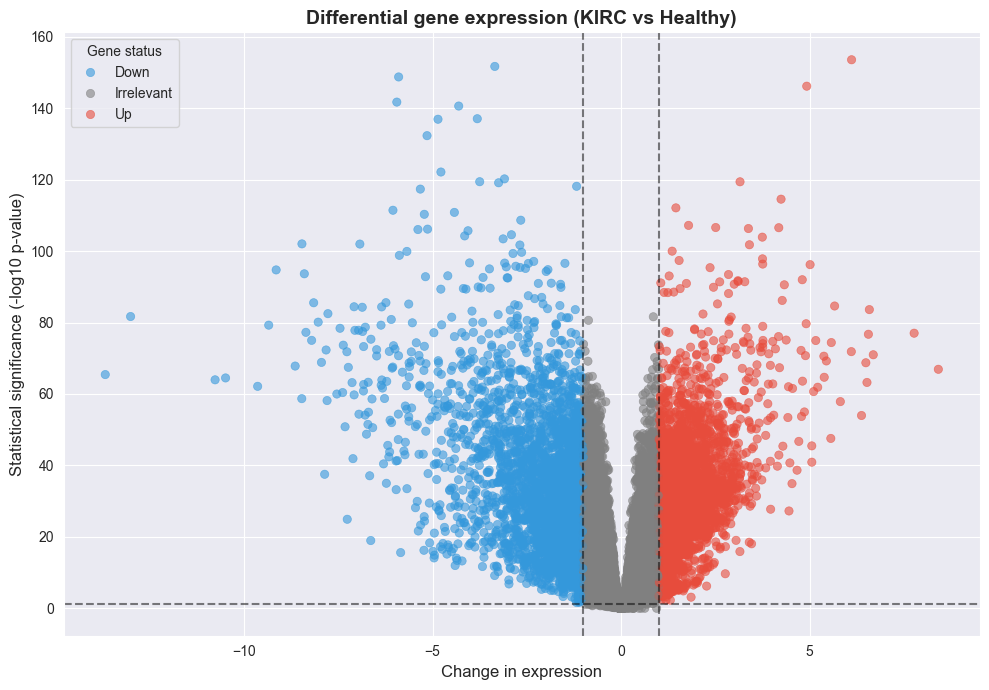

In [18]:
# DRAWING VOLCANO PLOT

plt.figure(figsize=(10, 7))
ax = sns.scatterplot(data=volcano_df, x='l2fc', y='neg_log_p', hue='sig',
                palette={'Irrelevant': 'grey', 'Up': '#e74c3c', 'Down': '#3498db'},
                alpha=0.6, edgecolor=None)

plt.axvline(1, color='black', linestyle='--', alpha=0.5)
plt.axvline(-1, color='black', linestyle='--', alpha=0.5)
plt.axhline(-np.log10(0.05), color='black', linestyle='--', alpha=0.5)

plt.title('Differential gene expression (KIRC vs Healthy)', fontsize=14, fontweight='bold')
plt.xlabel('Change in expression', fontsize=12)
plt.ylabel('Statistical significance (-log10 p-value)', fontsize=12)

plt.legend(title='Gene status', loc='upper left')

plt.tight_layout()
plt.savefig('volcano_plot_final.png', dpi=300)
plt.show()